# 最終課題

### スクレイピング

In [14]:
!pip install selenium webdriver-manager pandas

  Using cached selenium-4.39.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached webdriver_manager-4.0.2-py2.py3-none-any.whl.metadata (12 kB)
  Using cached trio-0.32.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached trio_websocket-0.12.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached outcome-1.3.0.post0-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached wsproto-1.3.2-py3-none-any.whl.metadata (5.2 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached selenium-4.39.0-py3-none-any.whl (9.7 MB)
Using cached webdriver_manager-4.0.2-py2.py3-none-any.whl (27 

In [22]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# --- 設定 ---
TARGET_URL = "https://www.ikyu.com/tokyo/140000/?adcid=202550369&adgid=12503541209&discsort=1&ikCo=google&ppc=2&rc=1"

options = Options()
# 確実性を高めるため、実際の動作を確認できるよう headless はオフ（ブラウザが立ち上がります）
options.add_argument('--no-sandbox')
options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
hotel_data = []

try:
    print(f"アクセス開始: {TARGET_URL}")
    driver.get(TARGET_URL)
    
    page_num = 1
    while True:
        print(f"\n--- 現在 {page_num} ページ目を解析中 ---")
        
        # ページが完全に読み込まれるまでしっかり待機
        time.sleep(5) 
        
        # ホテル名（h2）が含まれる要素をすべて取得（クラス名に依存しない）
        # sectionタグの中でh2を持っているものを探します
        cards = driver.find_elements(By.XPATH, "//section[.//h2]")
        
        if not cards:
            print("ホテル情報が見つかりませんでした。終了します。")
            break

        print(f"このページで {len(cards)} 件見つけました。")

        for card in cards:
            try:
                # ホテル名
                name = card.find_element(By.TAG_NAME, 'h2').text
                if not name: continue
                
                # 詳細リンク
                link = card.find_element(By.TAG_NAME, 'a').get_attribute('href')
                
                # テキストを解析
                lines = card.text.split('\n')
                area = lines[1] if len(lines) > 1 else "不明"
                
                # 価格と評価を抽出
                price = "不明"
                rating = "評価なし"
                for line in lines:
                    if "円" in line: price = line
                    if "点" in line: rating = line

                hotel_data.append({
                    "ホテル・旅館名": name,
                    "住所・エリア名": area,
                    "最低価格": price,
                    "レビュー評価": rating,
                    "詳細リンク": link
                })
            except:
                continue

        print(f"現在累計: {len(hotel_data)} 件取得済み")

        # --- 「次へ」ボタンの処理 ---
        try:
            # 共有いただいた画像の「次へ >」ボタンを探す
            # テキストに「次へ」を含む、または右矢印のアイコンがある要素を狙います
            next_buttons = driver.find_elements(By.XPATH, "//a[contains(., '次へ')] | //button[contains(., '次へ')]")
            
            if next_buttons:
                next_button = next_buttons[0]
                # ボタンまでスクロール
                driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", next_button)
                time.sleep(2)
                
                # クリック（JavaScriptで強制クリックすることで、他要素の被りを防ぐ）
                driver.execute_script("arguments[0].click();", next_button)
                page_num += 1
            else:
                print("「次へ」ボタンが見つかりません。全ページ完了しました。")
                break
        except Exception as e:
            print(f"次ページ移動中にエラー: {e}")
            break

finally:
    driver.quit()

# --- 保存 ---
if hotel_data:
    df = pd.DataFrame(hotel_data).drop_duplicates(subset=['ホテル・旅館名'])
    print(f"\n✅ 完了！合計 {len(df)} 件取得しました。")
    df.to_csv("ikyu_complete_list.csv", index=False, encoding="utf-8-sig")
    display(df)
else:
    print("データが1件も取得できませんでした。")

アクセス開始: https://www.ikyu.com/tokyo/140000/?adcid=202550369&adgid=12503541209&discsort=1&ikCo=google&ppc=2&rc=1

--- 現在 1 ページ目を解析中 ---
このページで 22 件見つけました。
現在累計: 22 件取得済み

--- 現在 2 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 46 件取得済み

--- 現在 3 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 70 件取得済み

--- 現在 4 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 94 件取得済み

--- 現在 5 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 118 件取得済み

--- 現在 6 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 142 件取得済み

--- 現在 7 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 166 件取得済み

--- 現在 8 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 190 件取得済み

--- 現在 9 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 214 件取得済み

--- 現在 10 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 238 件取得済み

--- 現在 11 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 262 件取得済み

--- 現在 12 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 286 件取得済み

--- 現在 13 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 310 件取得済み

--- 現在 14 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 334 件取得済み

--- 現在 15 ページ目を解析中 ---
このページで 24 件見つけました。
現在累計: 358 件取得済み

--- 現在 16 ページ目を解

,ホテル・旅館名,住所・エリア名,最低価格,レビュー評価,詳細リンク
0,帝国ホテル 東京,帝国ホテル 東京,"2名税込15,200円〜",世界的権威のあるトラベルガイド「フォーブス・トラベルガイド」のホテル部門にて、2016年に日系ホテルとして初めて5つ星を獲得して以降、毎年連続で5つ星の評価を獲得。2025年には、「ミシュランガイド」が発表するホテルの卓越性を示すミシュランキーにて最高評価である3ミシュランキーに2年連続で選ばれました。落ち着きと品格に満ちた「最上質の日本」が体験できるパレスホテル東京は、都心にありながら豊かな水と緑が溢れる丸の内1-1-1に佇みます。約6割の客室がバルコニー付き。窓を開け外に出ると、皇居外苑の豊かな緑が楽しめます。700点以上のアート作品に彩られた館内には、「ミシュランガイド東京2025」一つ星レストランであるフランス料理 エステール by アラン・デュカスをはじめ、会席の名店として長年多くの方々から愛される日本料理 和田倉や、和田倉濠に面したテラス席が人気のオールデイダイニング グランド キッチンなど、10の多彩なレストラン&バー、2024年より「フォーブス・トラベルガイド」のスパ部門にて5つ星の評価を得続けている、日本唯一のエビアン スパ 東京を備えています。世界が認めたラグジュアリーホテル パレスホテル東京でぜひ、上質な一日をお過ごしください。,https://www.ikyu.com/00000315/?discsort=1&lc=1&ppc=2&rc=1&st=1
2,ザ・ペニンシュラ東京,ザ・ペニンシュラ東京,"2名税込127,520円〜",米国の権威のある雑誌「フォーブス・トラベルガイド」のホテル部門にて最高ランク5つ星を8年連続で受賞するザ・ペニンシュラ東京は、皇居外苑と日比谷公園に面し、緑豊かな環境でありながら、銀座まで徒歩圏内という最高のロケーションです。和のテイストをとりいれたコンテンポラリーな客室に加え、アフタヌーンティーが代表的な「ザ・ロビー」や、本格的な広東料理をお楽しみいただける中国料理「ヘイフンテラス」、最上階の24階にて景色とお食事をご堪能いただけるモダンフレンチ「Peter」、そして贅沢で深いリラクゼーションに浸っていただける「ザ・ペニンシュラ スパ＆ウェルネスセンター」など、伝説的とも称されるペニンシュラ・ホスピタリティと共に、ペニンシュラならではのくつろぎの時間をご提供いたします。東京メトロ・都営地下鉄 日比谷駅に直結し、東京駅も近く、徒歩圏内には日生劇場や東京宝塚劇場、出光美術館など文化的な施設が点在しています。また、オフィス街でありながら、様々な個性的なショップが集まる丸の内エリアに位置し、一流ブランドやデパートが建ち並ぶ銀座・有楽町も至近で、ビジネスにもレジャーにも理想的な立地です。,https://www.ikyu.com/00001279/?discsort=1&lc=1&ppc=2&rc=1&st=1
3,品川プリンスホテル,東京都・品川駅（高輪口）より徒歩にて2分,"2名税込13,371円〜",評価なし,https://www.ikyu.com/00000660/?discsort=1&lc=1&ppc=2&rc=1&st=1
4,東京ステーションホテル,東京都・東京駅丸の内南口直結,"2名税込53,436円〜",評価なし,https://www.ikyu.com/00001833/?discsort=1&lc=1&ppc=2&rc=1&st=1
5,セルリアンタワー東急ホテル,東京都・渋谷駅徒歩5分,"2名税込56,904円〜",評価なし,https://www.ikyu.com/00000355/?discsort=1&lc=1&ppc=2&rc=1&st=1
6,The Okura Tokyo,The Okura Tokyo,"2名税込89,570円〜",評価なし,https://www.ikyu.com/00002620/?discsort=1&lc=1&ppc=2&rc=1&st=1
7,丸ノ内ホテル,東京都・東京駅丸の内北口 徒歩1分,"2名税込45,600円〜",評価なし,https://www.ikyu.com/00000816/?discsort=1&lc=1&ppc=2&rc=1&st=1
8,ふふ 東京 銀座,東京都・銀座一丁目,"2名税込89,350円〜",評価なし,https://www.ikyu.com/00003383/?discsort=1&lc=1&ppc=2&rc=1&st=1
9,東京ドームホテル,東京都・水道橋駅 徒歩2分,"2名税込20,350円〜",評価なし,https://www.ikyu.com/00000171/?discsort=1&lc=1&ppc=2&rc=1&st=1
10,グランドニッコー東京 台場,東京都・お台場,"2名税込22,640円〜",評価なし,https://www.ikyu.com/00000065/?discsort=1&lc=1&ppc=2&rc=1&st=1


### 分析

In [32]:
!pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


データベース 'hotel_analysis.db' を構築しました。
グラフ保存: hotel_counts_by_ward.png
グラフ保存: avg_price_by_area.png


/var/folders/25/cqlnrxhx6qbgbh7hyz4dzqwc0000gn/T/ipykernel_47614/3964135469.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='ward', data=df, palette='viridis')
/var/folders/25/cqlnrxhx6qbgbh7hyz4dzqwc0000gn/T/ipykernel_47614/3964135469.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_price', y='ward', data=df, palette='magma')


グラフ保存: cospa_analysis.png


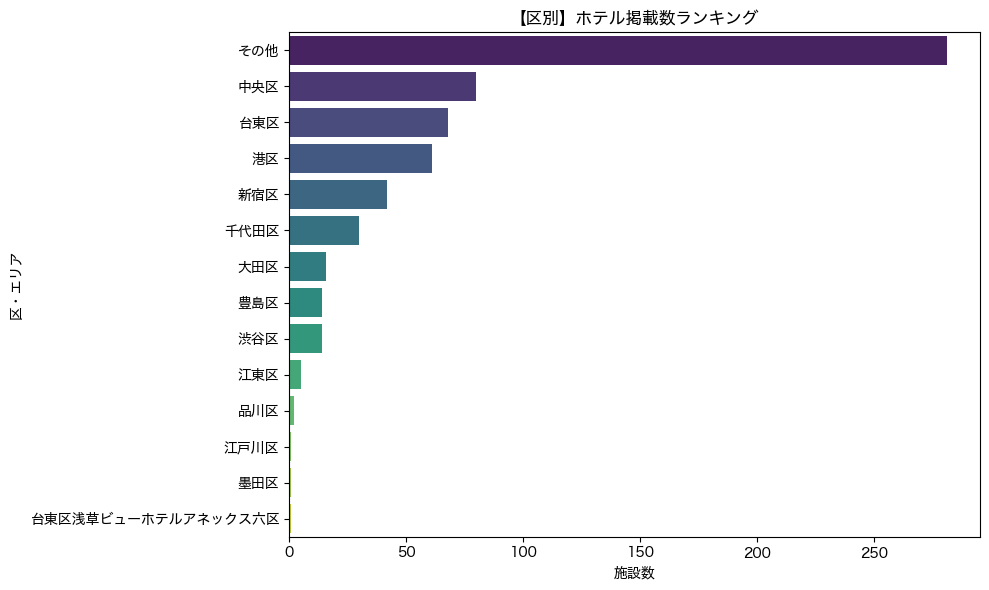

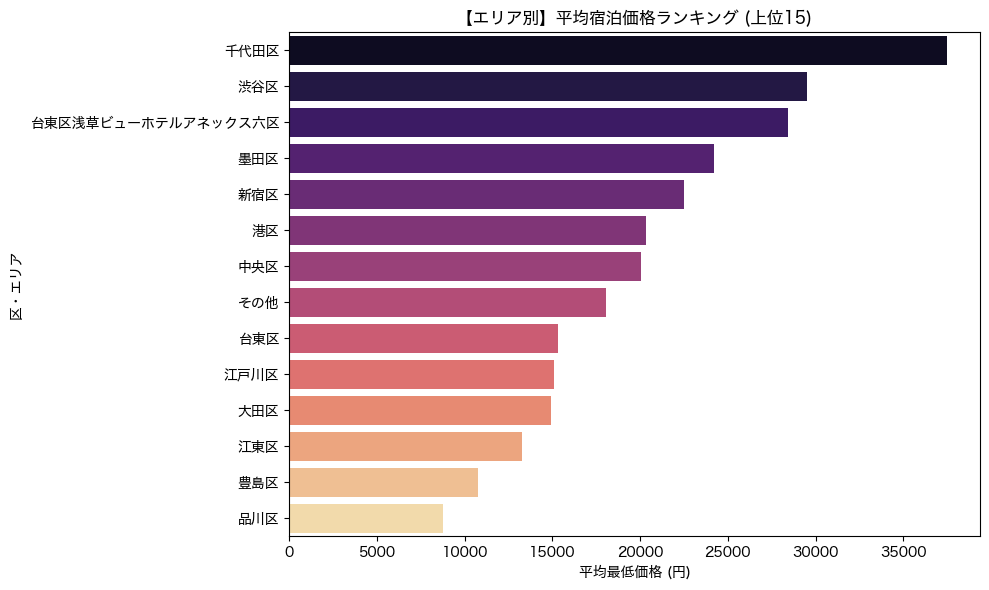

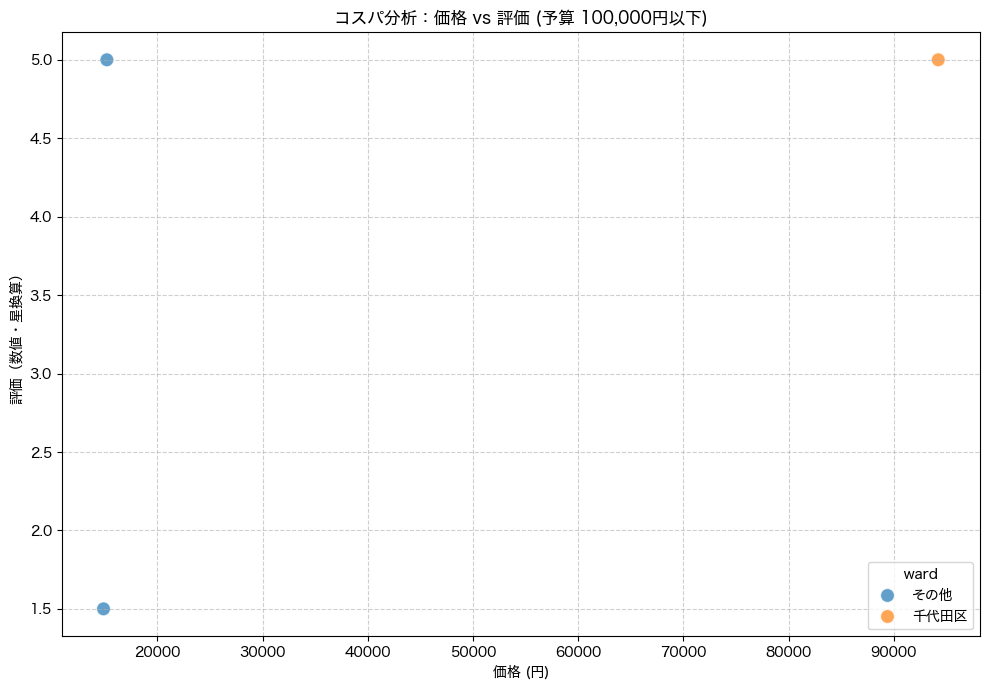

In [37]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# 日本語表示の設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Hiragino Sans', 'Arial Unicode MS', 'sans-serif']

class HotelDBAnalyzer:
    def __init__(self, csv_file, db_file='hotel_analysis.db'):
        self.db_file = db_file
        self.conn = sqlite3.connect(self.db_file)
        self._prepare_data(csv_file)

    def _prepare_data(self, csv_file):
        """CSVを読み込み、クレンジングしてDBに保存する"""
        df = pd.read_csv(csv_file)

        # 1. 価格の数値化 (例: "2名税込15,200円〜" -> 15200)
        def clean_price(x):
            nums = re.findall(r'\d+', str(x).replace(',', ''))
            return max([int(n) for n in nums]) if nums else None

        # 2. 評価の数値化 (例: "4.5" または "5つ星" -> 5.0)
        def clean_rating(x):
            text = str(x)
            # 数値を優先
            num_match = re.search(r'(\d\.\d+)', text)
            if num_match: return float(num_match.group(1))
            # 「5つ星」などのキーワードを変換
            if '5つ星' in text: return 5.0
            if '4つ星' in text: return 4.0
            return None

        # 3. 区 (Ward) の抽出
        def extract_ward(row):
            text = str(row['住所・エリア名']) + str(row['ホテル・旅館名'])
            ward_match = re.search(r'(\w+区)', text)
            if ward_match:
                return ward_match.group(1)
            # 地名からのマッピング（主要なもの）
            mapping = {
                '銀座': '中央区', '日本橋': '中央区', '築地': '中央区',
                '丸の内': '千代田区', '大手町': '千代田区', '秋葉原': '千代田区',
                '六本木': '港区', '赤坂': '港区', '新橋': '港区', '品川': '港区',
                '新宿': '新宿区', '渋谷': '渋谷区', '池袋': '豊島区', '上野': '台東区', '浅草': '台東区',
                '豊洲': '江東区', '羽田': '大田区'
            }
            for key, ward in mapping.items():
                if key in text: return ward
            return 'その他'

        df['price'] = df['最低価格'].apply(clean_price)
        df['rating'] = df['レビュー評価'].apply(clean_rating)
        df['ward'] = df.apply(extract_ward, axis=1)

        # DBへ保存
        df.to_sql('hotels', self.conn, if_exists='replace', index=False)
        print(f"データベース '{self.db_file}' を構築しました。")

    def run_query(self, sql, params=()):
        """SQLクエリを発行してDataFrameを返す"""
        return pd.read_sql_query(sql, self.conn, params=params)

    def plot_hotel_distribution(self):
        """どの区にホテルが多いかを集計・可視化"""
        sql = "SELECT ward, COUNT(*) as count FROM hotels GROUP BY ward ORDER BY count DESC"
        df = self.run_query(sql)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='count', y='ward', data=df, palette='viridis')
        plt.title('【区別】ホテル掲載数ランキング')
        plt.xlabel('施設数')
        plt.ylabel('区・エリア')
        plt.tight_layout()
        plt.savefig('hotel_counts_by_ward.png')
        print("グラフ保存: hotel_counts_by_ward.png")

    def plot_price_by_area(self, top_n=10):
        """エリア（区）別の平均価格を可視化"""
        sql = f"""
            SELECT ward, AVG(price) as avg_price 
            FROM hotels 
            WHERE price IS NOT NULL 
            GROUP BY ward 
            ORDER BY avg_price DESC 
            LIMIT {top_n}
        """
        df = self.run_query(sql)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='avg_price', y='ward', data=df, palette='magma')
        plt.title(f'【エリア別】平均宿泊価格ランキング (上位{top_n})')
        plt.xlabel('平均最低価格 (円)')
        plt.ylabel('区・エリア')
        plt.tight_layout()
        plt.savefig('avg_price_by_area.png')
        print("グラフ保存: avg_price_by_area.png")

    def plot_cospa_analysis(self, max_price=50000):
        """コスパ分析：価格と評価の相関"""
        sql = """
            SELECT price, rating, "ホテル・旅館名" as name, ward
            FROM hotels 
            WHERE price <= ? AND rating IS NOT NULL
        """
        df = self.run_query(sql, (max_price,))
        
        if df.empty:
            print("評価データが不足しているため、コスパグラフの生成をスキップします。")
            return

        plt.figure(figsize=(10, 7))
        sns.scatterplot(x='price', y='rating', hue='ward', data=df, s=100, alpha=0.7)
        plt.title(f'コスパ分析：価格 vs 評価 (予算 {max_price:,}円以下)')
        plt.xlabel('価格 (円)')
        plt.ylabel('評価（数値・星換算）')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.savefig('cospa_analysis.png')
        print("グラフ保存: cospa_analysis.png")

    def close(self):
        self.conn.close()

# --- 実行セクション ---
# CSVファイルを指定してアナライザーを起動
analyzer = HotelDBAnalyzer('ikyu_complete_list.csv')

# 1. 区別の施設数グラフを出力
analyzer.plot_hotel_distribution()

# 2. エリア別の平均価格グラフを出力
analyzer.plot_price_by_area(top_n=15)

# 3. 予算5万円以内での価格と評価の相関グラフを出力
analyzer.plot_cospa_analysis(max_price=100000)

analyzer.close()

データベース 'hotel_analysis.db' を構築しました。


/var/folders/25/cqlnrxhx6qbgbh7hyz4dzqwc0000gn/T/ipykernel_47614/690948945.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ward', y='price', data=df, palette='Set3')


グラフ保存: price_boxplot_by_ward.png
グラフ保存: hotel_type_distribution.png
グラフ保存: price_range_histogram.png


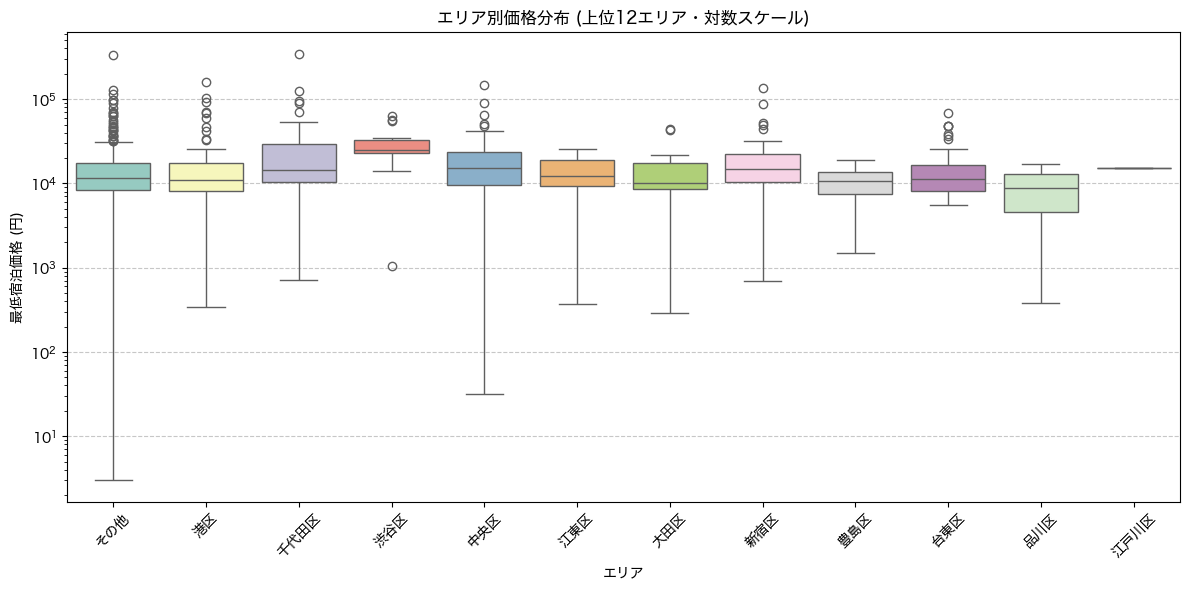

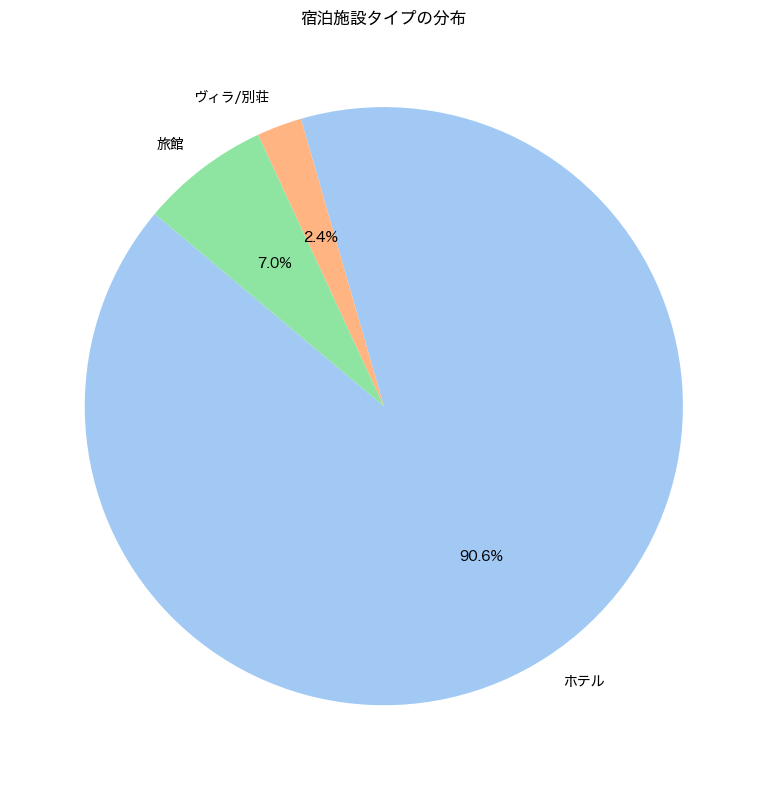

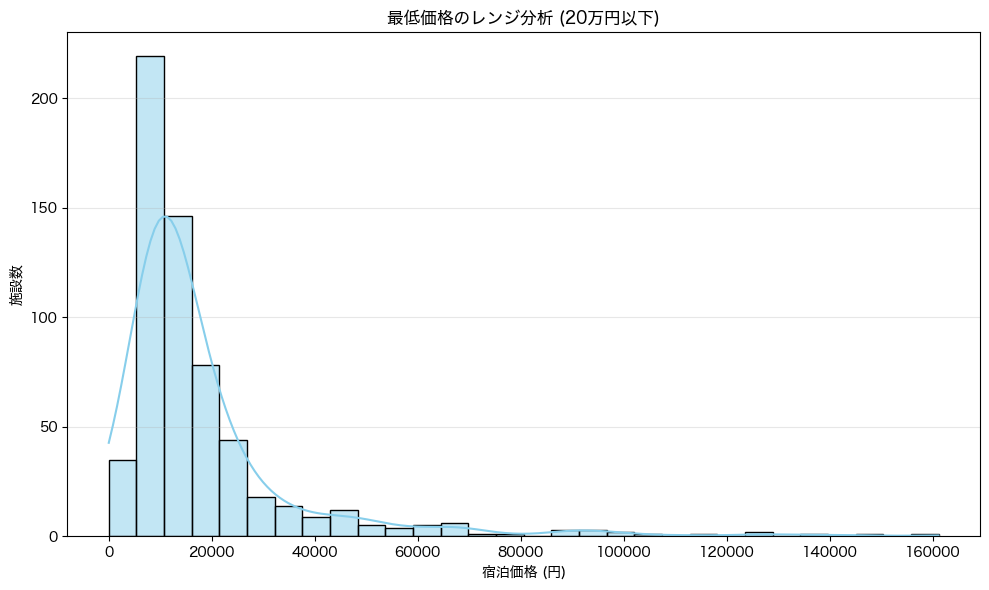

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# 日本語表示の設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Hiragino Sans', 'Arial Unicode MS', 'sans-serif']

class HotelDBAnalyzer:
    def __init__(self, csv_file, db_file='hotel_analysis.db'):
        self.db_file = db_file
        self.conn = sqlite3.connect(self.db_file)
        self._prepare_data(csv_file)

    def _prepare_data(self, csv_file):
        """CSVを読み込み、クレンジング・分類を行ってDBに保存する"""
        if not os.path.exists(csv_file):
            raise FileNotFoundError(f"ファイルが見つかりません: {csv_file}")
            
        df = pd.read_csv(csv_file)

        # 1. 価格の数値化
        def clean_price(x):
            nums = re.findall(r'\d+', str(x).replace(',', ''))
            return max([int(n) for n in nums]) if nums else None

        # 2. 評価の数値化
        def clean_rating(x):
            text = str(x)
            num_match = re.search(r'(\d\.\d+)', text)
            if num_match: return float(num_match.group(1))
            if '5つ星' in text: return 5.0
            if '4つ星' in text: return 4.0
            return None

        # 3. 区 (Ward) の抽出
        def extract_ward(row):
            text = str(row['住所・エリア名']) + str(row['ホテル・旅館名'])
            ward_match = re.search(r'(\w+区)', text)
            if ward_match: return ward_match.group(1)
            
            mapping = {
                '銀座': '中央区', '日本橋': '中央区', '築地': '中央区',
                '丸の内': '千代田区', '大手町': '千代田区', '秋葉原': '千代田区',
                '六本木': '港区', '赤坂': '港区', '新橋': '港区', '品川': '港区',
                '新宿': '新宿区', '渋谷': '渋谷区', '池袋': '豊島区', '上野': '台東区', '浅草': '台東区',
                '豊洲': '江東区', '羽田': '大田区'
            }
            for key, ward in mapping.items():
                if key in text: return ward
            return 'その他'

        # 4. 宿泊施設タイプの分類 (新規追加)
        def classify_type(name):
            name = str(name)
            if any(k in name for k in ['旅館', '温泉', '宿', '亭', '坊']):
                return '旅館'
            elif any(k in name for k in ['ヴィラ', '別荘', '離れ']):
                return 'ヴィラ/別荘'
            else:
                return 'ホテル'

        df['price'] = df['最低価格'].apply(clean_price)
        df['rating'] = df['レビュー評価'].apply(clean_rating)
        df['ward'] = df.apply(extract_ward, axis=1)
        df['hotel_type'] = df['ホテル・旅館名'].apply(classify_type)

        # DBへ保存
        df.to_sql('hotels', self.conn, if_exists='replace', index=False)
        print(f"データベース '{self.db_file}' を構築しました。")

    def run_query(self, sql, params=()):
        return pd.read_sql_query(sql, self.conn, params=params)

    ## --- 分析・可視化メソッド ---

    def plot_price_distribution_by_ward(self, top_n=10):
        """【エリア別の価格傾向】箱ひげ図で価格のばらつきを可視化"""
        # データ数の多い上位エリアを取得
        ward_counts = self.run_query("SELECT ward, COUNT(*) as count FROM hotels GROUP BY ward ORDER BY count DESC LIMIT ?", (top_n,))
        top_wards = ward_counts['ward'].tolist()
        
        sql = f"SELECT ward, price FROM hotels WHERE ward IN ({','.join(['?']*len(top_wards))}) AND price IS NOT NULL"
        df = self.run_query(sql, top_wards)

        plt.figure(figsize=(12, 6))
        sns.boxplot(x='ward', y='price', data=df, palette='Set3')
        plt.yscale('log')  # 価格差が激しいため対数スケール推奨
        plt.title(f'エリア別価格分布 (上位{top_n}エリア・対数スケール)')
        plt.xlabel('エリア')
        plt.ylabel('最低宿泊価格 (円)')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig('price_boxplot_by_ward.png')
        print("グラフ保存: price_boxplot_by_ward.png")

    def plot_hotel_type_distribution(self):
        """【宿泊施設タイプの分布】円グラフで割合を可視化"""
        sql = "SELECT hotel_type, COUNT(*) as count FROM hotels GROUP BY hotel_type"
        df = self.run_query(sql)

        plt.figure(figsize=(8, 8))
        plt.pie(df['count'], labels=df['hotel_type'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
        plt.title('宿泊施設タイプの分布')
        plt.tight_layout()
        plt.savefig('hotel_type_distribution.png')
        print("グラフ保存: hotel_type_distribution.png")

    def plot_price_range_analysis(self):
        """【最低価格のレンジ分析】ヒストグラムで価格帯のボリューム層を可視化"""
        sql = "SELECT price FROM hotels WHERE price IS NOT NULL AND price < 200000"
        df = self.run_query(sql)

        plt.figure(figsize=(10, 6))
        sns.histplot(df['price'], bins=30, kde=True, color='skyblue')
        plt.title('最低価格のレンジ分析 (20万円以下)')
        plt.xlabel('宿泊価格 (円)')
        plt.ylabel('施設数')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('price_range_histogram.png')
        print("グラフ保存: price_range_histogram.png")

    def close(self):
        self.conn.close()

# --- 実行セクション ---
if __name__ == "__main__":
    # 1. 初期化とデータ読み込み
    # ※ 'ikyu_complete_list.csv' がカレントディレクトリにある前提
    analyzer = HotelDBAnalyzer('ikyu_complete_list.csv')

    # 2. エリア別の価格傾向分析 (箱ひげ図)
    # どのエリアが高価格帯に寄っているか、または格安から高級まで幅広いかが見えます
    analyzer.plot_price_distribution_by_ward(top_n=12)

    # 3. 宿泊施設タイプの分布 (円グラフ)
    # ホテル、旅館、ヴィラなどの比率を可視化します
    analyzer.plot_hotel_type_distribution()

    # 4. 最低価格のレンジ分析 (ヒストグラム)
    # 最もボリュームの大きい価格帯（例：1万〜2万円など）を特定します
    analyzer.plot_price_range_analysis()

    analyzer.close()

1名あたり価格の計算が完了しました。
グラフ保存: unit_price_by_ward.png
グラフ保存: unit_price_segments.png


/var/folders/25/cqlnrxhx6qbgbh7hyz4dzqwc0000gn/T/ipykernel_47614/938591992.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_unit_price', y='ward', data=df, palette='flare')


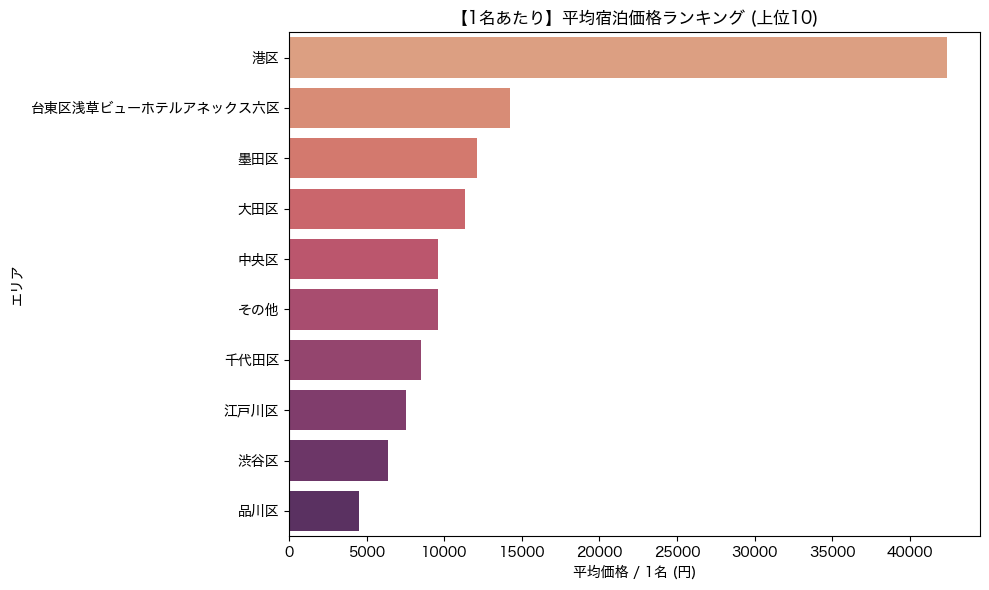

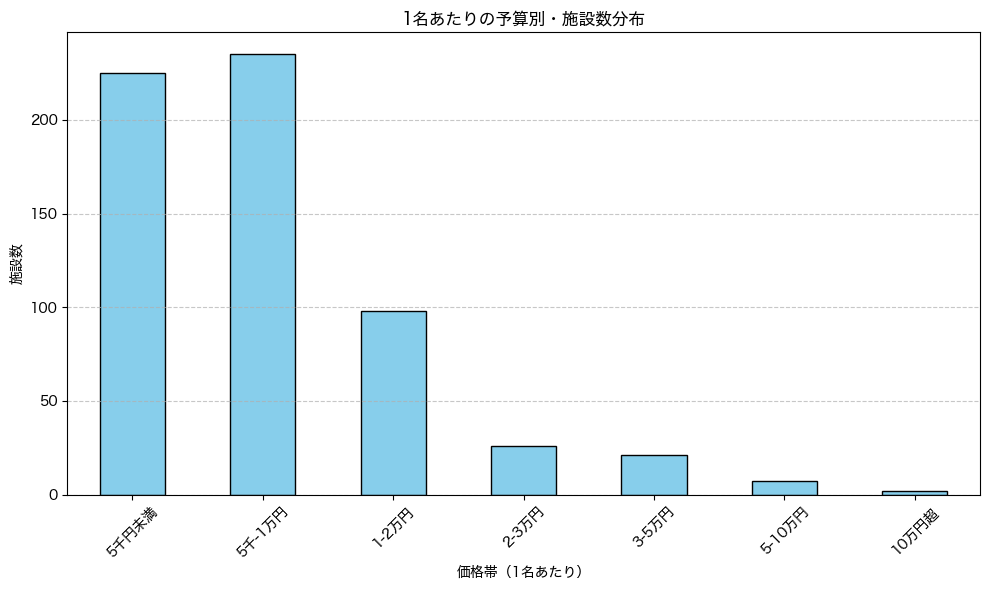

In [40]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# 日本語表示の設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Hiragino Sans', 'Arial Unicode MS', 'sans-serif']

class HotelPricePerPersonAnalyzer:
    def __init__(self, csv_file, db_file='hotel_analysis.db'):
        self.db_file = db_file
        self.conn = sqlite3.connect(self.db_file)
        self._prepare_data(csv_file)

    def _prepare_data(self, csv_file):
        df = pd.read_csv(csv_file)

        def calculate_per_person_price(price_text):
            """
            "2名税込15,000円〜" -> 7500
            "1名12,000円" -> 12000
            などの形式から1人あたりの単価を計算する
            """
            text = str(price_text).replace(',', '')
            
            # 数値の抽出
            nums = re.findall(r'\d+', text)
            if not nums: return None
            
            # 1. 人数の特定 (「〇名」という表現を探す)
            person_match = re.search(r'(\d+)名', text)
            num_people = int(person_match.group(1)) if person_match else 1
            
            # 2. 総額の特定 (一番大きい数値を価格とみなす)
            total_price = max([int(n) for n in nums])
            
            # 3. 1名あたりの価格算出
            return total_price / num_people

        # データクレンジング
        df['unit_price'] = df['最低価格'].apply(calculate_per_person_price)
        
        # エリア（区）抽出（前回のロジックを流用）
        def extract_ward(row):
            text = str(row['住所・エリア名']) + str(row['ホテル・旅館名'])
            ward_match = re.search(r'(\w+区)', text)
            return ward_match.group(1) if ward_match else 'その他'

        df['ward'] = df.apply(extract_ward, axis=1)

        # DBへ保存
        df.to_sql('hotels', self.conn, if_exists='replace', index=False)
        print("1名あたり価格の計算が完了しました。")

    def run_query(self, sql):
        return pd.read_sql_query(sql, self.conn)

    def plot_unit_price_by_ward(self, top_n=10):
        """1名あたりの平均宿泊単価が高いエリアランキング"""
        sql = f"""
            SELECT ward, AVG(unit_price) as avg_unit_price 
            FROM hotels 
            WHERE unit_price IS NOT NULL 
            GROUP BY ward 
            ORDER BY avg_unit_price DESC 
            LIMIT {top_n}
        """
        df = self.run_query(sql)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='avg_unit_price', y='ward', data=df, palette='flare')
        plt.title(f'【1名あたり】平均宿泊価格ランキング (上位{top_n})')
        plt.xlabel('平均価格 / 1名 (円)')
        plt.ylabel('エリア')
        plt.tight_layout()
        plt.savefig('unit_price_by_ward.png')
        print("グラフ保存: unit_price_by_ward.png")

    def plot_price_segmentation(self):
        """1名あたりの価格帯セグメント（予算別分布）"""
        sql = "SELECT unit_price FROM hotels WHERE unit_price IS NOT NULL"
        df = self.run_query(sql)

        # 価格帯のカテゴリ分け
        bins = [0, 5000, 10000, 20000, 30000, 50000, 100000, float('inf')]
        labels = ['5千円未満', '5千-1万円', '1-2万円', '2-3万円', '3-5万円', '5-10万円', '10万円超']
        df['price_range'] = pd.cut(df['unit_price'], bins=bins, labels=labels)
        
        range_counts = df['price_range'].value_counts().reindex(labels)

        plt.figure(figsize=(10, 6))
        range_counts.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title('1名あたりの予算別・施設数分布')
        plt.xlabel('価格帯（1名あたり）')
        plt.ylabel('施設数')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig('unit_price_segments.png')
        print("グラフ保存: unit_price_segments.png")

    def close(self):
        self.conn.close()

# --- 実行 ---
if __name__ == "__main__":
    analyzer = HotelPricePerPersonAnalyzer('ikyu_complete_list.csv')
    
    # 1名あたりのエリア別平均価格
    analyzer.plot_unit_price_by_ward()
    
    # 1名あたりの価格帯ボリューム層の可視化
    analyzer.plot_price_segmentation()
    
    analyzer.close()